# SPX volatility surface: from the raw CBOE chain to a clean smile

How a raw SPX option chain becomes a clean IV smile and term structure, with the reasoning
behind each choice. Decisions are logged in `docs/DECISIONS.md`.

- **IV source.** CBOE's published `cboe_iv`, used to validate the clean -> slice -> surface
  pipeline (ADR 006). Our own Black-Scholes solver is a later milestone.
- **Data.** One SPX snapshot off CBOE's delayed feed (timestamp in the first cell). CBOE's
  terms forbid redistribution, so the raw chain is gitignored (ADR 001) and the rendered
  outputs are the deliverable.
- **Read, don't re-run.** The prose is written to this snapshot. To run it live, call
  `download_chain()` and point `PINNED` at your date; your market won't match the narrative.
  Expiries are picked by nearest day-target, so the code survives any snapshot.

In [119]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engine.data import load_chain, chain_to_frame, download_chain
from engine.filters import bidask_mask, expiry_mask
from engine.surface import forward_by_expiry, implied_forwards, select_otm
# (staleness_mask / volume_mask stay in engine.filters but aren't v1 filters; see §3)

# colorblind-safe palette (Wong): identity, kept-vs-dropped, roots, maturity ramp
C_CALL, C_PUT = "#0173B2", "#DE8F05"
C_KEEP, C_DROP = "#029E73", "#BBBBBB"
C_SPX, C_SPXW = "#CC3311", "#0077BB"
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [120]:
# --- the one snapshot this analysis is built on (raw chain gitignored, ADR 001) ---
# To run on your own data: download_chain() to fetch+save a snapshot, then set PINNED to
# its date. load_chain reads disk only and raises FileNotFoundError if you don't have it.
PINNED = "2026-07-13"
raw = load_chain(PINNED)
df  = chain_to_frame(raw)

ASOF_TS = df.attrs["asof"]                    # full quote timestamp, the provenance stamp
ASOF    = ASOF_TS.normalize()                 # midnight, for day counts downstream
SPOT    = df.attrs["spot"]                    # cash index level at the snapshot

print(f"SPX chain as of {ASOF_TS}  (CBOE delayed feed)")
print(f"{len(df):,} contracts | spot {SPOT:,.1f} | "
      f"roots {df['root'].unique().tolist()} | {df['expiry'].nunique()} expiries")

SPX chain as of 2026-07-13 21:19:31  (CBOE delayed feed)
29,486 contracts | spot 7,515.3 | roots ['SPX', 'SPXW'] | 56 expiries


In [121]:
# --- helpers: day counts, target-driven expiry picking, and the clean pipeline ---

def days_to(exp) -> int:
    """Calendar days from the snapshot to an expiry."""
    return int((pd.Timestamp(exp) - ASOF).days)


def nearest_expiry(expiries, target_days: int):
    """The listed expiry closest to `target_days` out (never a hardcoded date)."""
    exps = pd.DatetimeIndex(pd.Series(expiries).drop_duplicates())
    d = (exps - ASOF).days.to_numpy()
    return exps[np.abs(d - target_days).argmin()]


def build_clean(frame, r: float = 0.04):
    """Raw chain -> clean OTM quotes on a moneyness axis (the v1 pipeline, ADR 009/011).

    bid/ask>0 + T>0  ->  parity forward per expiry  ->  keep the OTM side  ->  moneyness
    m = ln(K/F). Adds columns F and m. (Trade-count filters,
    staleness and volume, are dropped from v1: they discard tight never-traded quotes, which are fine off the mid.
    A spread-based liquidity filter is the deferred next step.)
    """
    d = frame[bidask_mask(frame) & expiry_mask(frame)].copy()
    d["F"] = d["expiry"].map(forward_by_expiry(d, r))
    d = d.dropna(subset=["F"])
    d = d[select_otm(d)].copy()
    d["m"] = np.log(d["strike"] / d["F"])
    return d


def pick_slice(clean, target_days: int):
    """Nearest-to-target expiry, preferring SPXW on overlap (the root-blend rule, ADR 004).

    Returns (expiry, days, slice_frame, root).
    """
    exp = nearest_expiry(clean["expiry"], target_days)
    sl = clean[clean["expiry"] == exp]
    root = "SPXW" if (sl["root"] == "SPXW").any() else "SPX"
    return exp, days_to(exp), sl[sl["root"] == root], root


CLEAN = build_clean(df)
print(f"clean OTM quotes: {len(CLEAN):,} across {CLEAN['expiry'].nunique()} expiries")

clean OTM quotes: 13,574 across 55 expiries


## 1. Coverage by root and maturity

Each dot is one expiry, showing how many clean options it lists. The two roots split the
maturity axis.

- **SPXW** (PM-settled) lists weeklies out to about a year. Thin per date, but available
  every week, which is where near-term granularity comes from.
- **SPX** (AM-settled) lists monthlies, quarterlies and LEAPS out to 2031, with no weeklies.
  Rich per date, but sparse.

So we blend them (ADR 004): SPXW near, SPX at the long end. Only 5 dates list both, and at
those we default to SPXW, which covers the practical smile (to roughly ±1 log-moneyness).
SPX's extra strikes there are deep tail, down to 0.05x spot, which v1 doesn't need.

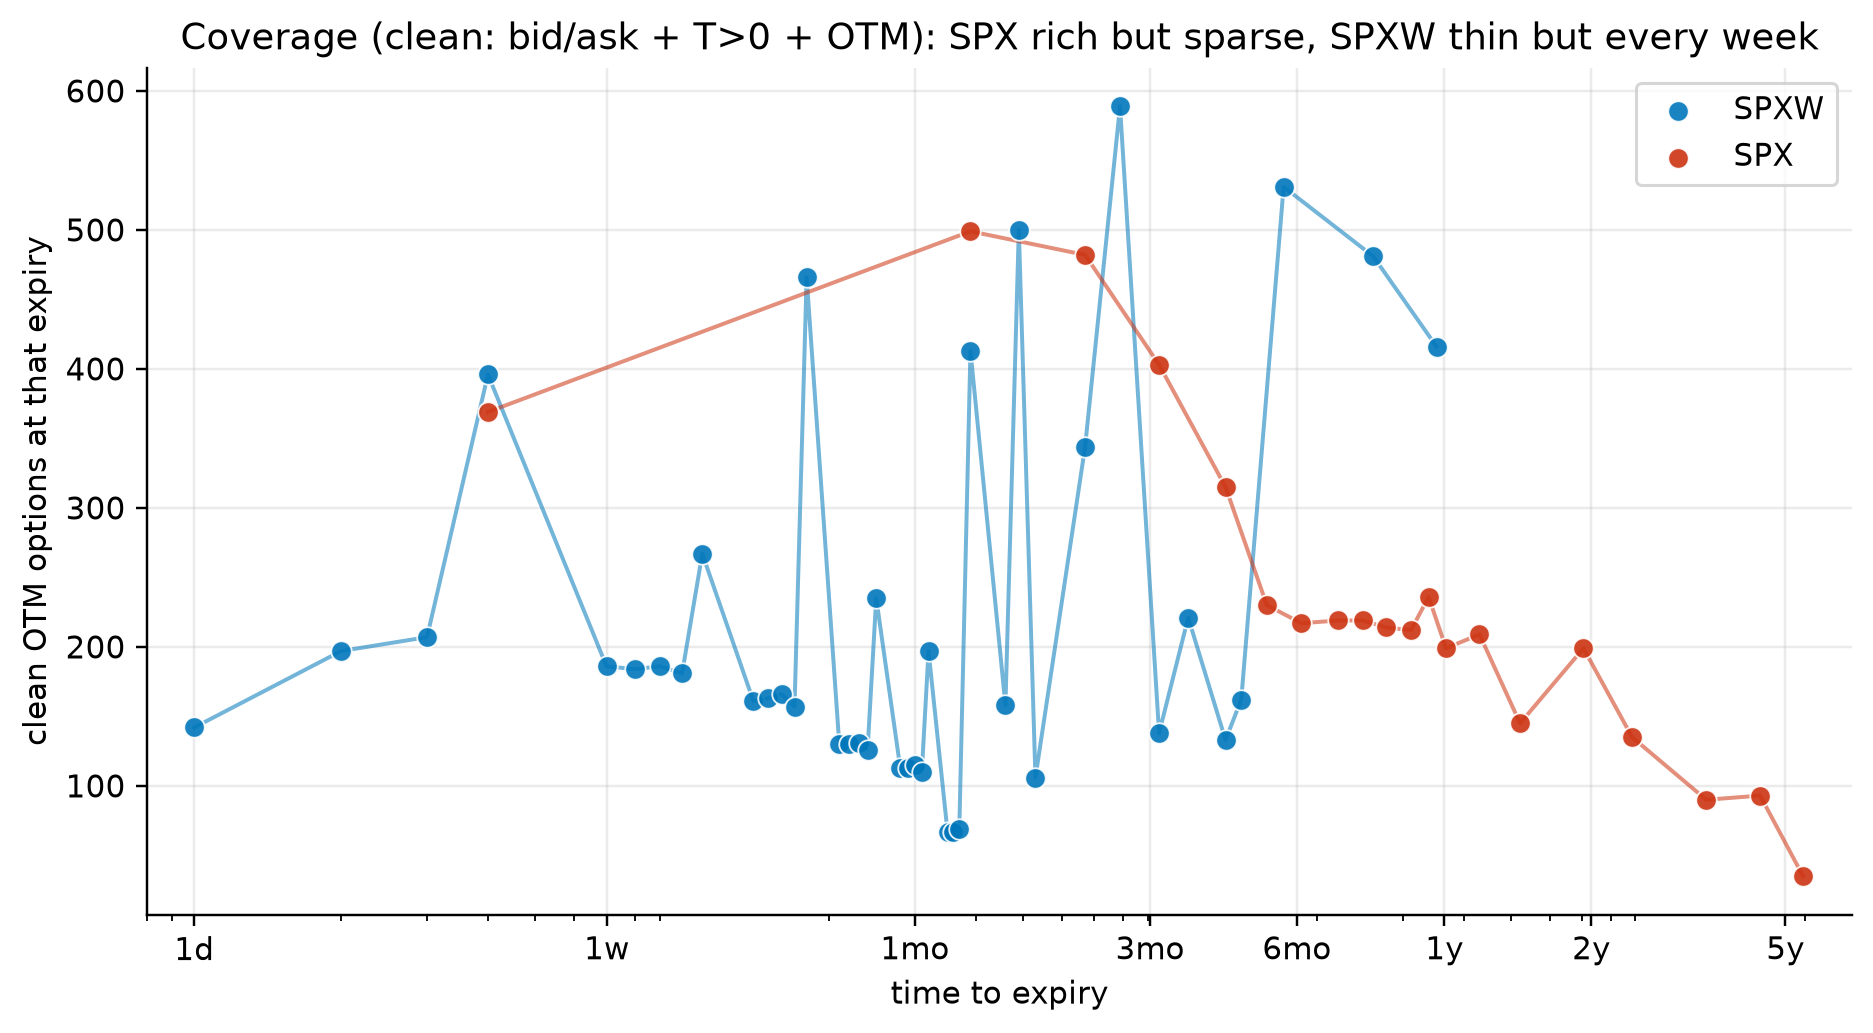

the clean pipeline keeps 13,574 of 29,486 listed contracts (46%)


In [122]:
# coverage of the CLEAN pipeline output (bid/ask + T>0 + OTM), one point per expiry
cov = CLEAN.groupby(["root", "expiry"]).size().rename("n").reset_index()
cov["days"] = (cov["expiry"] - ASOF).dt.days
cov = cov[cov["days"] >= 1]                       # drop 0DTE (undefined on a log axis)

fig, ax = plt.subplots(figsize=(10, 5))
for root, c in [("SPXW", C_SPXW), ("SPX", C_SPX)]:
    s = cov[cov["root"] == root].sort_values("days")
    ax.plot(s["days"], s["n"], color=c, lw=1.3, alpha=0.55, zorder=2)          # guide line
    ax.scatter(s["days"], s["n"], s=45, color=c, label=root, alpha=0.9,
               edgecolor="white", linewidth=0.6, zorder=3)                     # the data
ax.set_xscale("log")
ax.set_xticks([1, 7, 30, 91, 182, 365, 730, 1825])
ax.set_xticklabels(["1d", "1w", "1mo", "3mo", "6mo", "1y", "2y", "5y"])
ax.set_xlim(0.8, 2500)
ax.set_xlabel("time to expiry")
ax.set_ylabel("clean OTM options at that expiry")
ax.set_title("Coverage (clean: bid/ask + T>0 + OTM): SPX rich but sparse, SPXW thin but every week")
ax.legend()
plt.show()

print(f"the clean pipeline keeps {len(CLEAN):,} of {len(df):,} listed contracts "
      f"({len(CLEAN)/len(df):.0%})")

## 2. Convergence between the roots

Where both roots list the same expiry we can difference their IVs strike by strike. Near
term, the AM/PM settlement gap makes them disagree by about 0.4 vol pts a few days out. By a
few months the median disagreement falls to about 0.05 vol pts. Handing the near term to
SPXW and the long end to SPX therefore introduces no visible seam, because the two have
already converged by the maturity where the handoff happens.

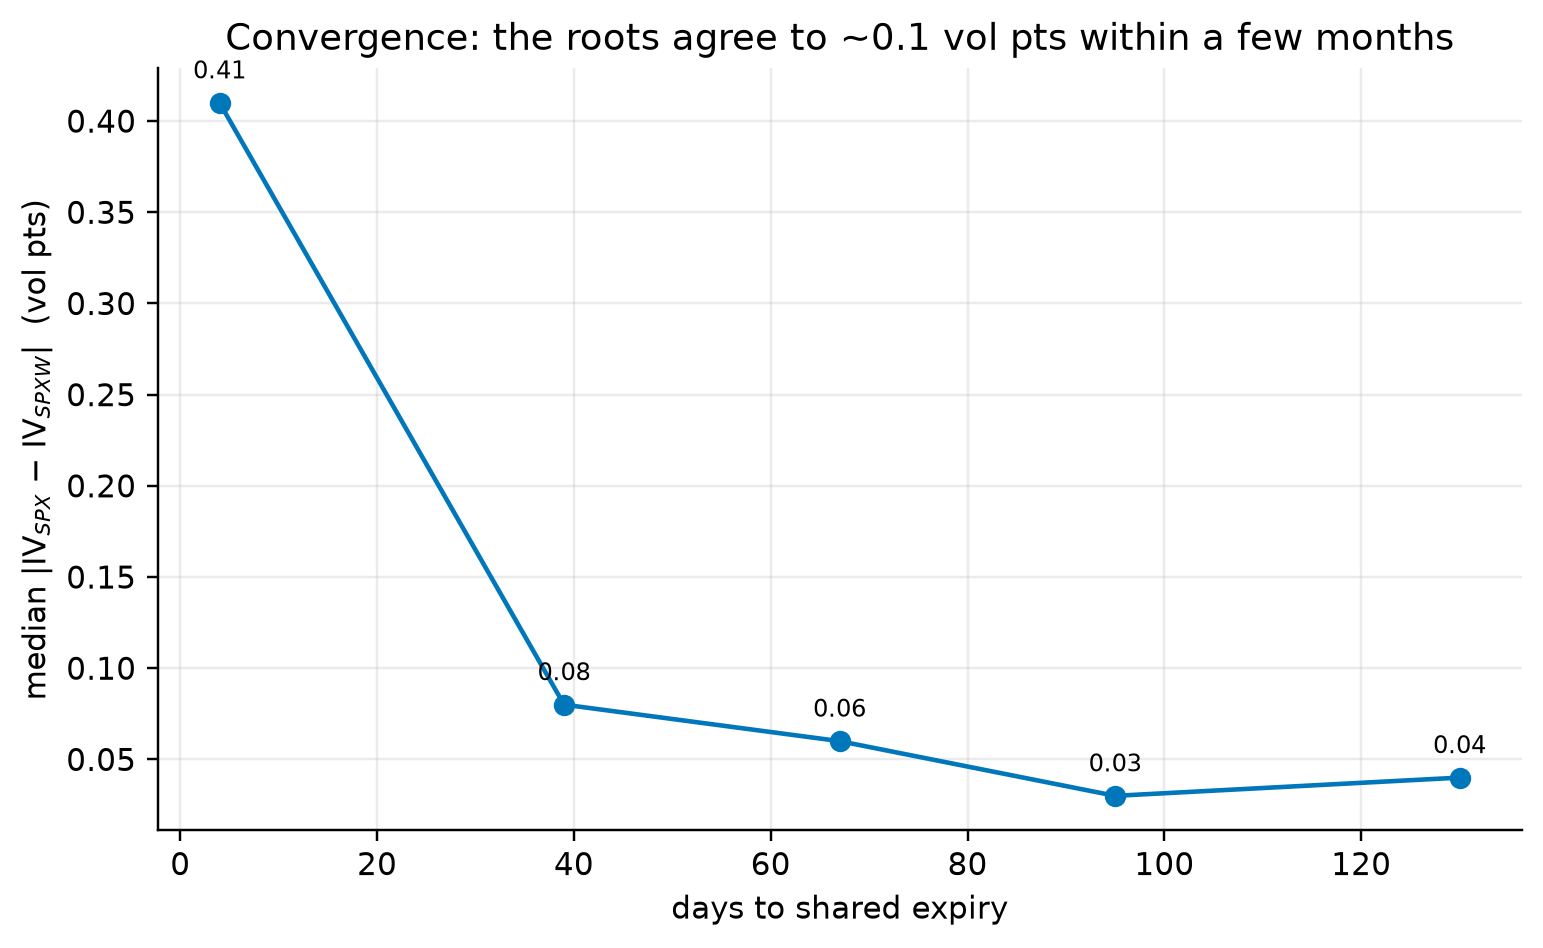

In [123]:
qc = df[bidask_mask(df) & expiry_mask(df)].copy()
qc["F"] = qc["expiry"].map(forward_by_expiry(qc))
qc = qc.dropna(subset=["F"])
qc = qc[select_otm(qc) & (qc["cboe_iv"] > 0)]          # compare only reliable OTM IVs

piv = qc.pivot_table(index=["expiry", "type", "strike"], columns="root", values="cboe_iv")
piv = piv.dropna(subset=["SPX", "SPXW"])                # strikes listed under BOTH roots
piv["ad"] = (piv["SPX"] - piv["SPXW"]).abs() * 100      # vol points
conv = piv.groupby("expiry")["ad"].median()
cd = pd.DataFrame({"days": [days_to(e) for e in conv.index], "vp": conv.values}).sort_values("days")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cd["days"], cd["vp"], "-o", color=C_SPXW, ms=6)
for _, row in cd.iterrows():
    ax.annotate(f"{row['vp']:.2f}", (row["days"], row["vp"]),
                textcoords="offset points", xytext=(0, 8), fontsize=8, ha="center")
ax.set_xlabel("days to shared expiry")
ax.set_ylabel(r"median |IV$_{SPX}$ − IV$_{SPXW}$|  (vol pts)")
ax.set_title("Convergence: the roots agree to ~0.1 vol pts within a few months")
plt.show()

## 3. Filters: dropping unusable quotes

Two quality gates on the raw chain. Both judge a quote on its own terms, so no forward is
needed yet and the axis here is the raw strike (spot dashed).

- **T > 0.** This snapshot was taken after the close, so it still carries 490 contracts of
  that day's expiry. An expired option is pure intrinsic value, so no implied vol exists;
  Black-76's `d1/d2` divide by `sigma*sqrt(T) = 0`. CBOE publishes `0.0` for 467 of them and
  values up to 837% for the rest (ADR 011).
- **bid/ask > 0.** Drop contracts with no bid or no ask, where nobody is quoting that side
  and the mid is meaningless. These sit in the far wings: 7 quotes on the slice below, at
  `bid 0.00 / ask 0.15`, marked grey. Chain-wide the gate removes 1,168.

The flat row of zeros at the bottom left passes both gates. Those are deep ITM calls
(K=3000 bids 4511, almost pure intrinsic) where CBOE publishes no IV. They are on the wrong
side of the strike rather than badly quoted, and §4 removes them.

Trade-count filters (volume, staleness) were tried and dropped: they discard tight
never-traded market-maker quotes, which are fine when you price off the mid. A spread-based
liquidity filter is the deferred next step (ADR 009).

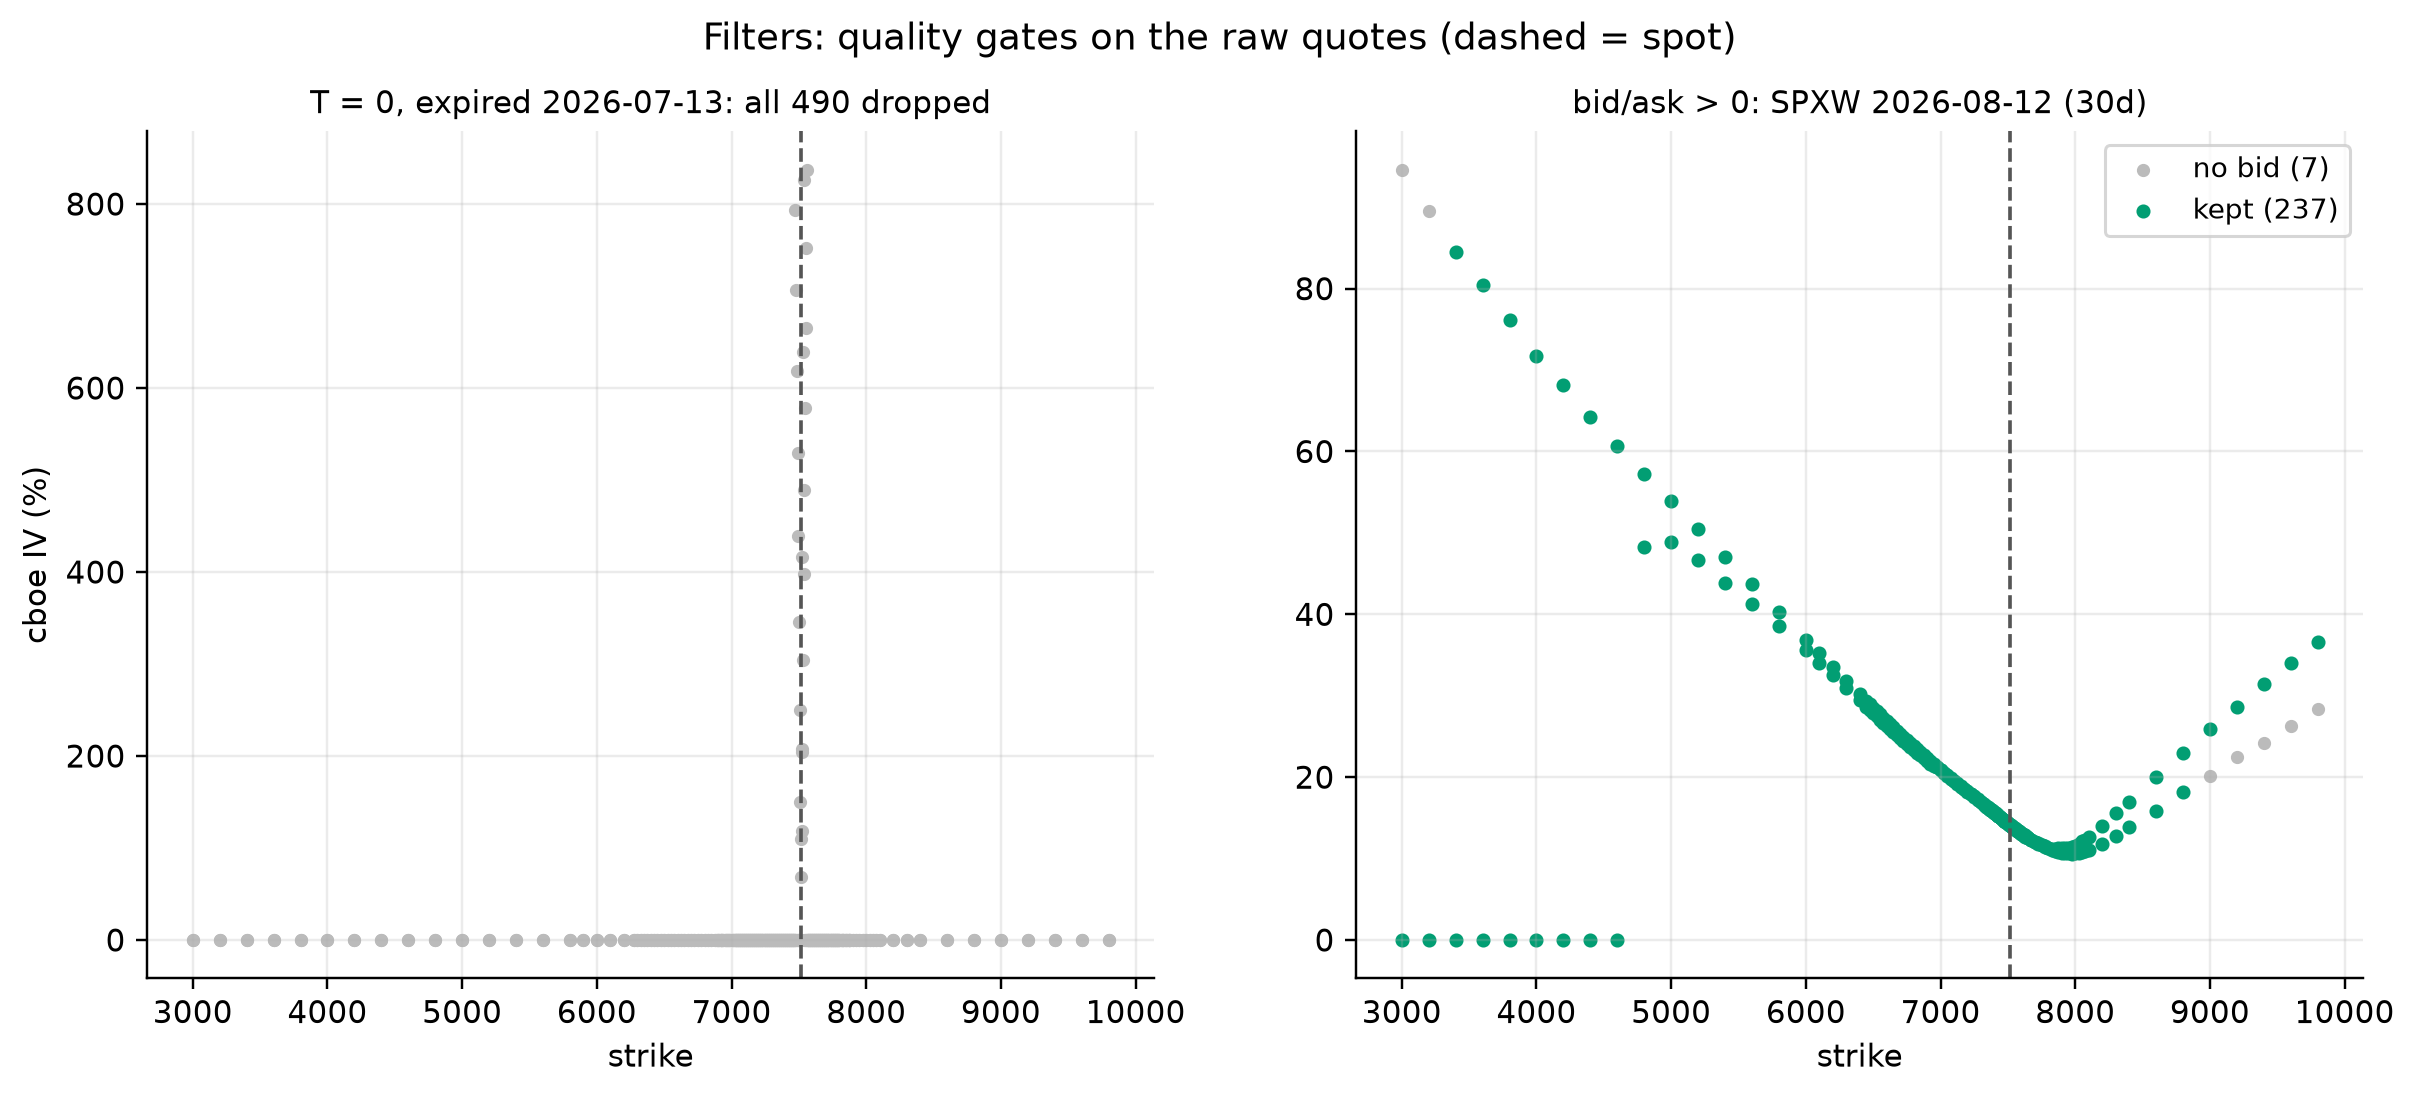

raw 29,486  ->  bid/ask 28,318  ->  + T>0 28,072


In [124]:
exp30, d30, _, root30 = pick_slice(CLEAN, 30)          # the reference ~30d expiry

zero = df[~expiry_mask(df)]                                    # the already-settled expiry
b30  = df[(df["expiry"] == exp30) & (df["root"] == root30)]    # one live ~30d expiry
keep = bidask_mask(b30)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(zero["strike"], zero["cboe_iv"] * 100, s=11, color=C_DROP)
axes[0].set_title(f"T = 0, expired {pd.Timestamp(zero['expiry'].iloc[0]).date()}: "
                  f"all {len(zero)} dropped", fontsize=10)

axes[1].scatter(b30.loc[~keep, "strike"], b30.loc[~keep, "cboe_iv"] * 100, s=11,
                color=C_DROP, label=f"no bid ({int((~keep).sum())})")
axes[1].scatter(b30.loc[keep, "strike"], b30.loc[keep, "cboe_iv"] * 100, s=13,
                color=C_KEEP, label=f"kept ({int(keep.sum())})")
axes[1].set_title(f"bid/ask > 0: {root30} {pd.Timestamp(exp30).date()} ({d30}d)", fontsize=10)
axes[1].legend(fontsize=9)

for ax in axes:
    ax.axvline(SPOT, color="#555555", ls="--", lw=1.2)
    ax.set_xlabel("strike")
axes[0].set_ylabel("cboe IV (%)")
fig.suptitle("Filters: quality gates on the raw quotes (dashed = spot)", fontsize=12)
plt.show()

print(f"raw {len(df):,}  ->  bid/ask {int(bidask_mask(df).sum()):,}  "
      f"->  + T>0 {int((bidask_mask(df) & expiry_mask(df)).sum()):,}")

## 4. The forward

The moneyness axis needs a forward `F` per expiry. Rather than guess SPX's dividend yield,
read it off the prices themselves via put-call parity: `F = K + e^{rT}(C - P)` (ADR 003).
`C - P` doesn't depend on vol, so every strike of an expiry should imply the same `F`, which
makes the spread across strikes a free quality check. We take the median.

`F` also decides which side of each strike to keep: the OTM side, puts below `F` and calls
above. The ITM twin carries the same implied vol on a much wider quote, so it adds nothing.

What survives goes on `m = ln(K/F)`, one normalized axis that is comparable across expiries.

In [125]:
qf = df[(df["expiry"] == exp30) & (df["root"] == root30) & bidask_mask(df) & expiry_mask(df)]
imp = implied_forwards(qf)
print(f"{root30} {pd.Timestamp(exp30).date()} ({d30}d): {len(imp)} call+put pairs, "
      f"F = {imp['F'].median():.1f} ± {imp['F'].std():.2f} across strikes")
imp.head()

SPXW 2026-08-12 (30d): 115 call+put pairs, F = 7536.3 ± 0.53 across strikes


type,root,expiry,strike,T,F
0,SPXW,2026-08-12,3400.0,0.082192,7536.150976
1,SPXW,2026-08-12,3600.0,0.082192,7536.194665
2,SPXW,2026-08-12,3800.0,0.082192,7537.191482
3,SPXW,2026-08-12,4000.0,0.082192,7536.256960
4,SPXW,2026-08-12,4200.0,0.082192,7536.325731


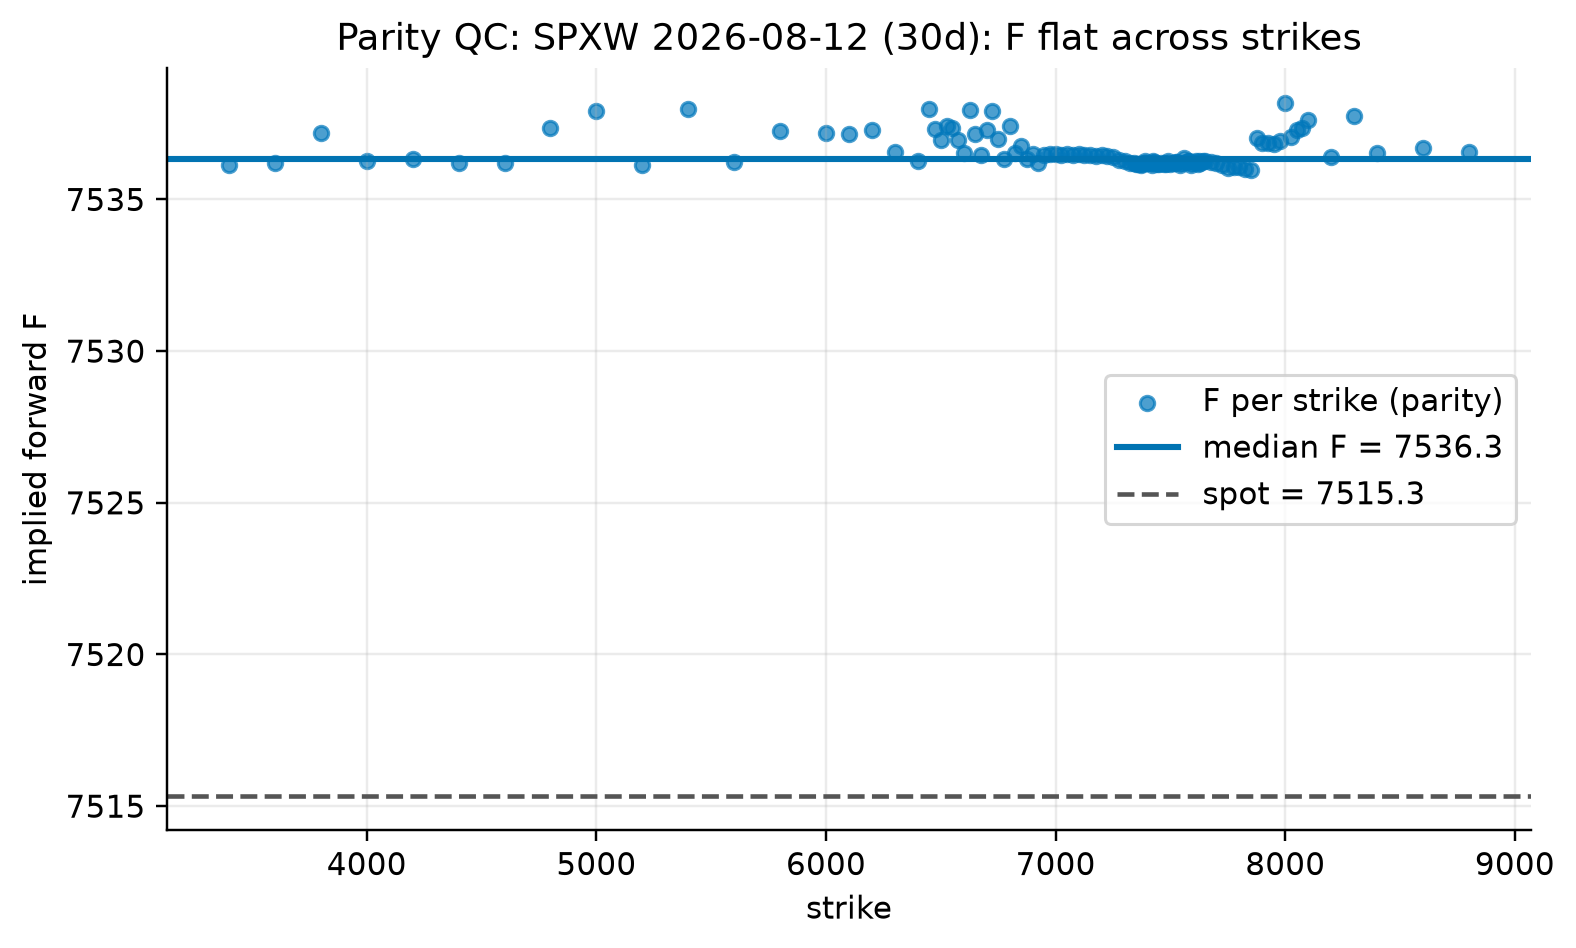

In [126]:
Fmed = imp["F"].median()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(imp["strike"], imp["F"], s=22, color=C_SPXW, alpha=0.7, label="F per strike (parity)")
ax.axhline(Fmed, color=C_CALL, lw=2, label=f"median F = {Fmed:.1f}")
ax.axhline(SPOT, color="#555555", ls="--", lw=1.5, label=f"spot = {SPOT:.1f}")
ax.set_xlabel("strike")
ax.set_ylabel("implied forward F")
ax.set_title(f"Parity QC: {root30} {pd.Timestamp(exp30).date()} ({d30}d): F flat across strikes")
ax.legend()
plt.show()

## 5. The smile

Everything above, applied to one ~30-day expiry: bad quotes and expired contracts removed,
cut to the OTM side, placed on the moneyness axis from §4. This is the clean slice the
surface gets built from.

The downward slope to the left is the equity skew. Crash protection is bid up, so
out-of-the-money puts carry higher IV than calls.

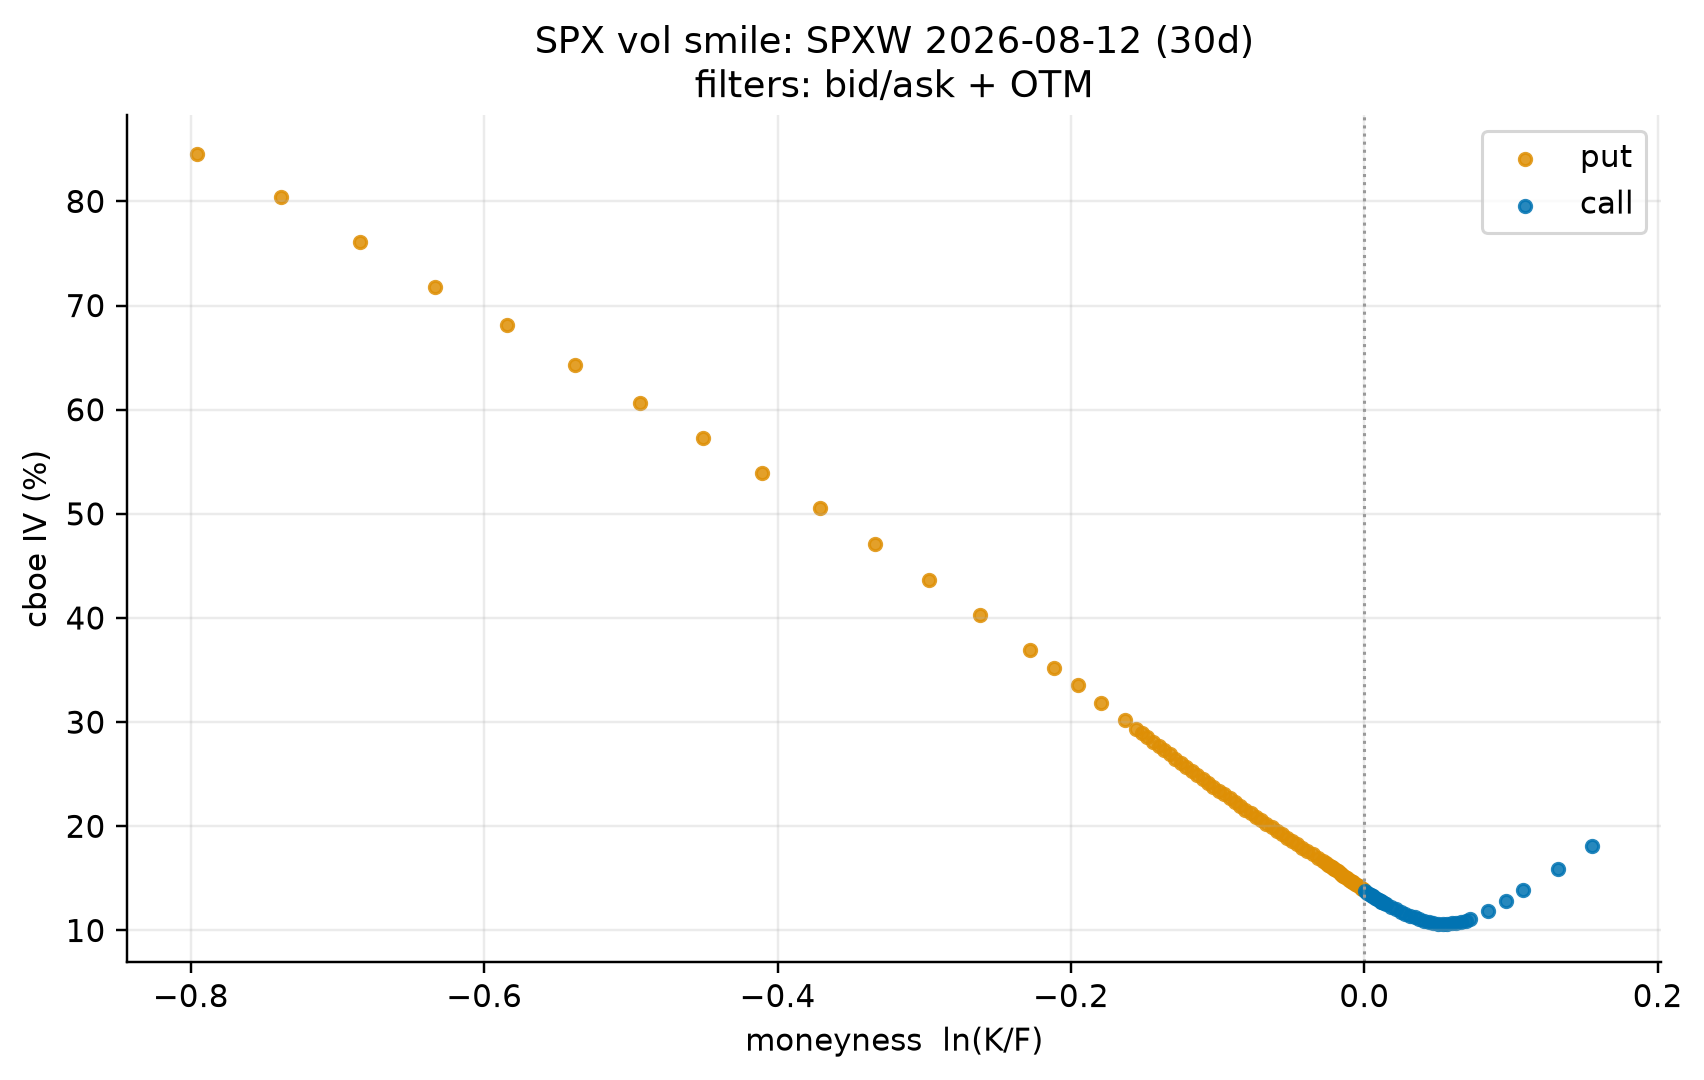

In [127]:
_, _, sl30, _ = pick_slice(CLEAN, 30)
fig, ax = plt.subplots(figsize=(9, 5))
for t, c, lab in [("P", C_PUT, "put"), ("C", C_CALL, "call")]:
    s = sl30[sl30["type"] == t].sort_values("m")
    ax.scatter(s["m"], s["cboe_iv"] * 100, s=16, color=c, label=lab, alpha=0.85)
ax.axvline(0, color="#999", lw=1, ls=":")
ax.set_xlabel("moneyness  ln(K/F)")
ax.set_ylabel("cboe IV (%)")
ax.set_title(f"SPX vol smile: {root30} {pd.Timestamp(exp30).date()} ({d30}d)\n"
             f"filters: bid/ask + OTM")
ax.legend()
plt.show()

## 6. Term structure

The same clean smile at roughly 30, 90, 180 and 365 days, blended across roots. Near-term
skew is steepest, since a shock matters most when there is little time to recover. As
maturity grows the smile flattens and lifts. This 2-D fan is one moneyness slice of the full
`(moneyness, T)` surface.

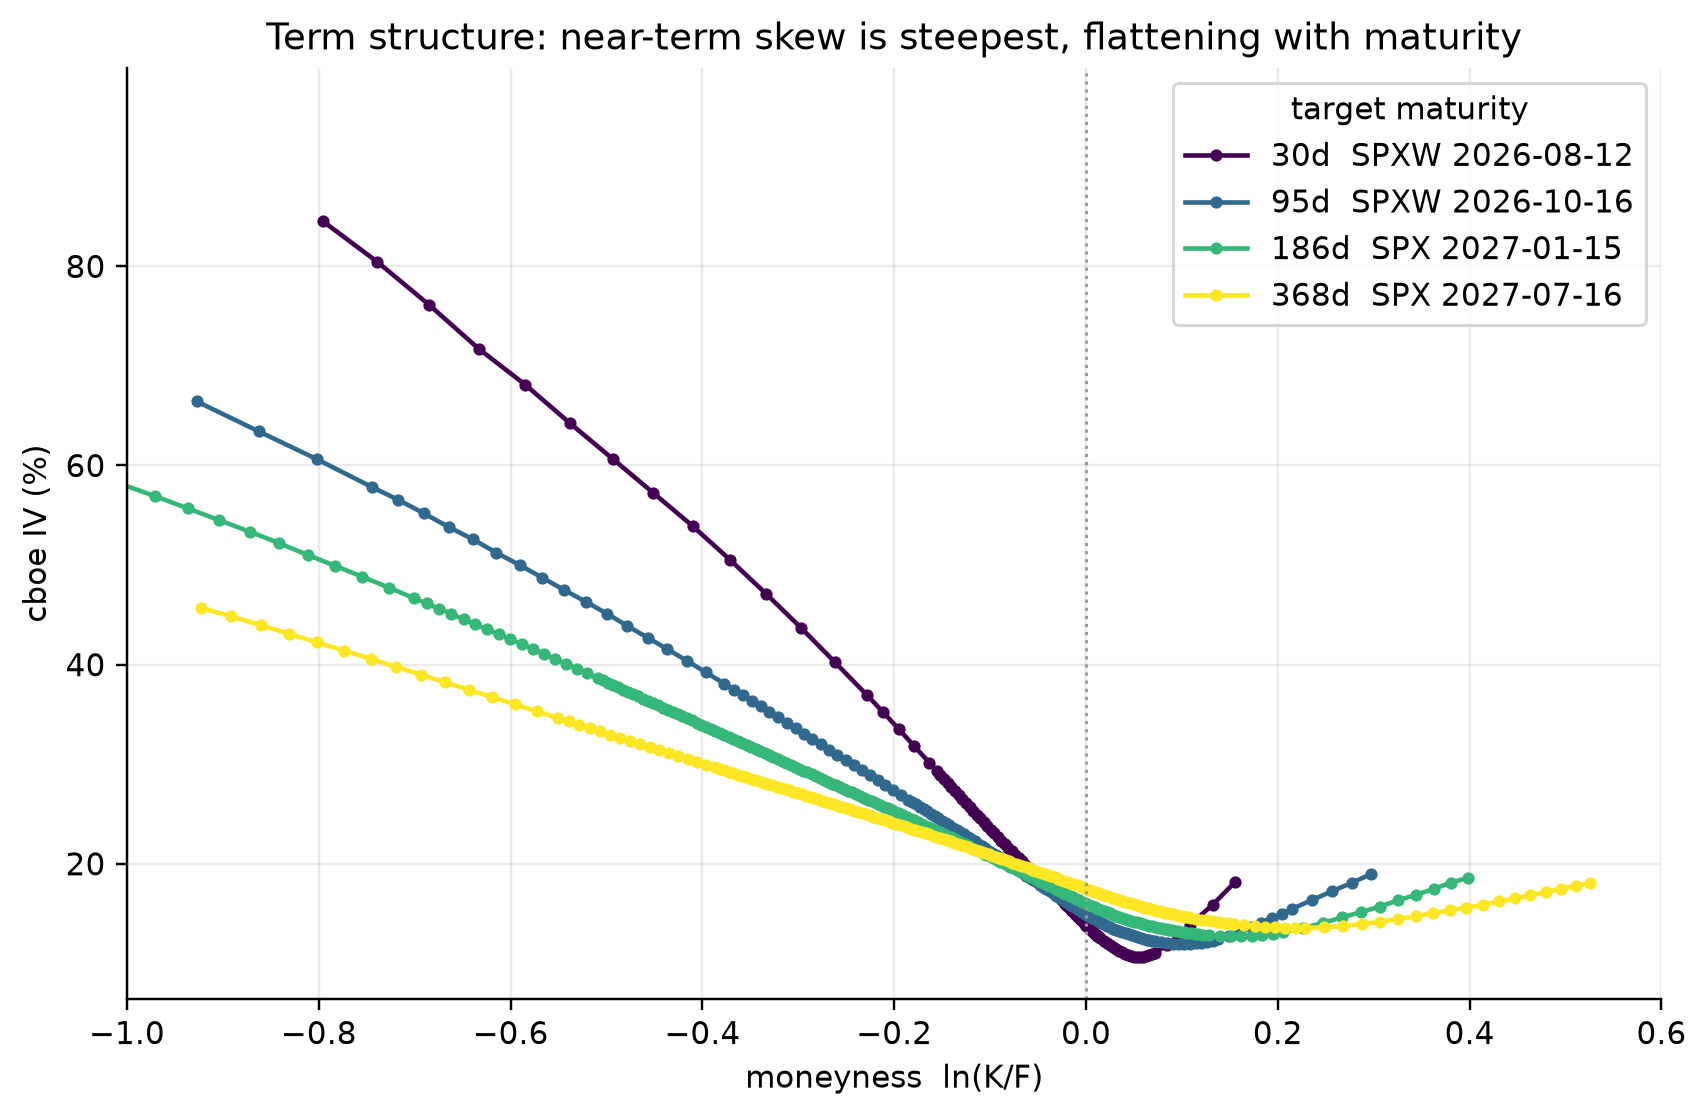

In [128]:
targets = [30, 90, 180, 365]
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(9, 5.5))
for i, td in enumerate(targets):
    exp, dd, sl, root = pick_slice(CLEAN, td)
    s = sl.sort_values("m")
    ax.plot(s["m"], s["cboe_iv"] * 100, "-o", ms=3,
            color=cmap(i / (len(targets) - 1)),
            label=f"{dd}d  {root} {pd.Timestamp(exp).date()}")
ax.axvline(0, color="#999", lw=1, ls=":")
ax.set_xlim(-1.0, 0.6)
ax.set_xlabel("moneyness  ln(K/F)")
ax.set_ylabel("cboe IV (%)")
ax.set_title("Term structure: near-term skew is steepest, flattening with maturity")
ax.legend(title="target maturity")
plt.show()

---
### Where this goes next

This is the raw cleaned surface: CBOE's IV on real, liquid quotes. Its moneyness coverage is
ragged by construction, with narrow near-term wings, wider coverage in the middle and sparse
data far out, following liquidity and scaling with sqrt(T). The next milestones consolidate
it into a smooth, arbitrage-free surface (see `docs/STATE.md`):

- our own Black-Scholes IV solver, swapped in for `cboe_iv`;
- an SVI/SSVI fit, filling the ragged wings into a consistent `(moneyness, T)` grid with
  sqrt(T) scaling built in;
- a no-arbitrage (monotonicity) check.

Deferred cleaning: the median+MAD spread-outlier filter.

Decisions behind this notebook: ADR 001 (data), 003 (parity forward), 004 (root blend),
006 (cboe_iv v1), 009 (filters), 011 (T>0).